# PCO213 — Trabalho Final
## Previsão de Preço de Carros Usados com Aprendizado de Máquina

**Disciplina:** PCO213 — Aprendizado de Máquina e Mineração de Dados  
**Dataset:** Car details v3.csv (mercado indiano de carros usados)  
**Problema:** Regressão — prever `selling_price` a partir de características do veículo.

Este notebook segue o roteiro exigido pelo projeto: EDA, pré-processamento, modelagem com cross-validation, interpretação e comparação de modelos.


In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

RANDOM_STATE = 42
DATA_PATH = Path("datasets/Car details v3.csv")


## 1. Carregamento e limpeza dos dados


In [2]:
def parse_mileage(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"([0-9]+\.?[0-9]*)", str(value))
    return float(match.group(1)) if match else np.nan


def parse_engine(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"([0-9]+)", str(value))
    return float(match.group(1)) if match else np.nan


def parse_power(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"([0-9]+\.?[0-9]*)", str(value))
    return float(match.group(1)) if match else np.nan


def parse_torque(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"([0-9]+\.?[0-9]*)", str(value))
    return float(match.group(1)) if match else np.nan


def extract_brand(name):
    if pd.isna(name):
        return "Unknown"
    return str(name).split()[0]


def load_and_clean(path=DATA_PATH):
    df = pd.read_csv(path)
    print(f"Registros brutos: {len(df):,}")
    print(f"Duplicatas: {df.duplicated().sum():,}")

    df = df.drop_duplicates().copy()
    print(f"Após remoção de duplicatas: {len(df):,}")

    df["brand"] = df["name"].apply(extract_brand)
    df["mileage_kmpl"] = df["mileage"].apply(parse_mileage)
    df["engine_cc"] = df["engine"].apply(parse_engine)
    df["max_power_bhp"] = df["max_power"].apply(parse_power)
    df["torque_nm"] = df["torque"].apply(parse_torque)

    price_low, price_high = df["selling_price"].quantile([0.01, 0.99])
    km_low, km_high = df["km_driven"].quantile([0.01, 0.99])
    year_low = 1990

    mask = (
        (df["selling_price"] >= price_low)
        & (df["selling_price"] <= price_high)
        & (df["km_driven"] >= km_low)
        & (df["km_driven"] <= km_high)
        & (df["year"] >= year_low)
    )
    removed = (~mask).sum()
    df = df.loc[mask].copy()
    print(f"Outliers removidos: {removed:,}")
    print(f"Dataset final: {len(df):,}")

    return df


df = load_and_clean()
df.head()


Registros brutos: 8,128
Duplicatas: 1,202
Após remoção de duplicatas: 6,926
Outliers removidos: 263
Dataset final: 6,663


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,brand,mileage_kmpl,engine_cc,max_power_bhp,torque_nm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,Maruti,23.40,1248.0,74.00,190.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,Skoda,21.14,1498.0,103.52,250.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,Honda,17.70,1497.0,78.00,12.7
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,Hyundai,23.00,1396.0,90.00,22.4
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,Maruti,16.10,1298.0,88.20,11.5


## 2. Análise exploratória (EDA)


In [3]:
numeric_cols = [
    "year", "selling_price", "km_driven", "seats",
    "mileage_kmpl", "engine_cc", "max_power_bhp", "torque_nm",
]

print("Estatísticas descritivas:")
display(df[numeric_cols].describe().T.round(2))

print("\nValores ausentes (%):")
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
display(missing_pct[missing_pct > 0].round(2))


Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
year,6663.0,2013.49,3.88,1991.0,2011.0,2014.00,2017.00,2020.00
selling_price,6663.0,483698.62,347947.31,52000.0,250000.0,400000.00,625000.00,2700000.00
km_driven,6663.0,72192.98,42541.06,5000.0,40000.0,70000.00,100000.00,239451.00
seats,6467.0,5.43,0.97,2.0,5.0,5.00,5.00,14.00
mileage_kmpl,6467.0,19.57,4.02,0.0,17.0,19.68,22.54,33.44
engine_cc,6467.0,1419.52,477.00,624.0,1197.0,1248.00,1498.00,3498.00
max_power_bhp,6469.0,86.81,29.28,0.0,68.0,81.83,98.97,272.00
torque_nm,6466.0,159.34,86.76,4.8,96.1,150.00,200.00,789.00



Valores ausentes (%):


torque_nm        2.96
torque           2.96
mileage          2.94
engine_cc        2.94
mileage_kmpl     2.94
seats            2.94
engine           2.94
max_power_bhp    2.91
max_power        2.90
dtype: float64

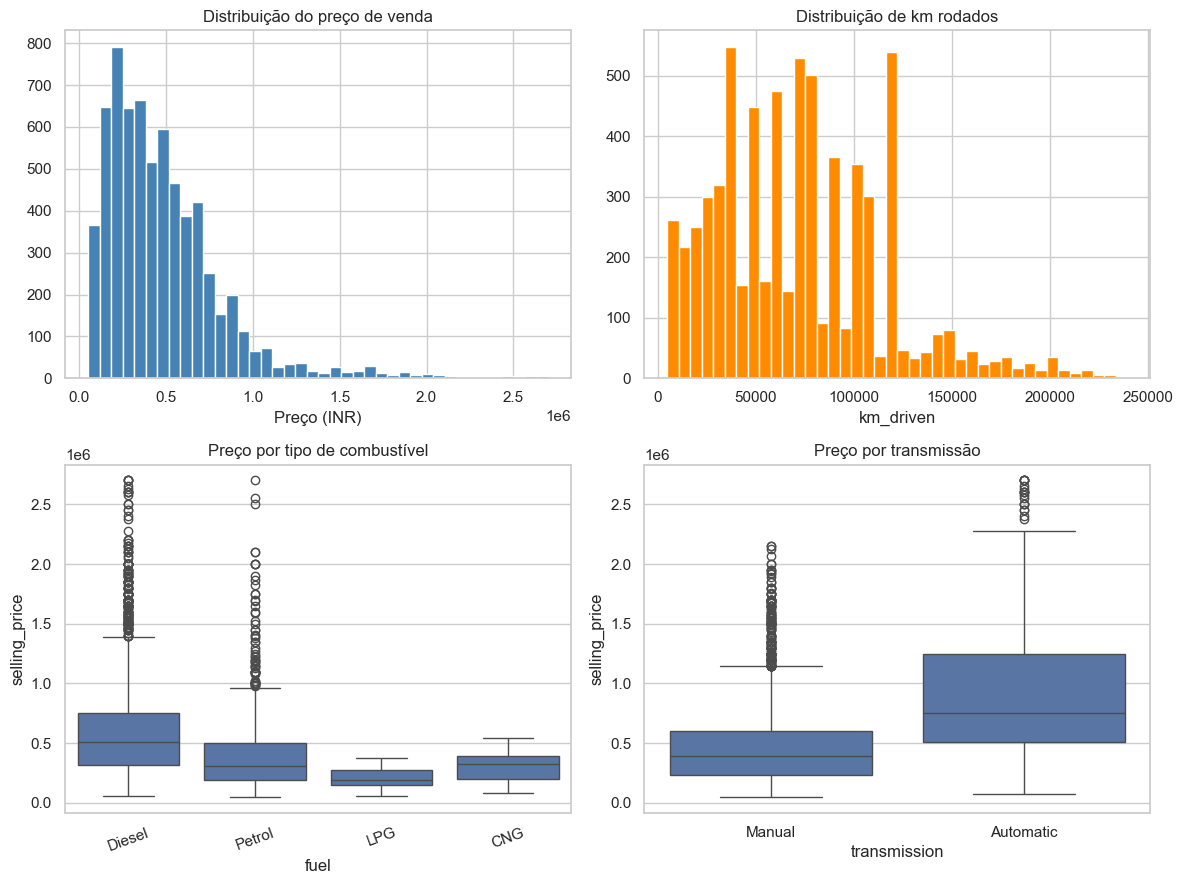

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(df["selling_price"], bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribuição do preço de venda")
axes[0, 0].set_xlabel("Preço (INR)")

axes[0, 1].hist(df["km_driven"], bins=40, color="darkorange", edgecolor="white")
axes[0, 1].set_title("Distribuição de km rodados")
axes[0, 1].set_xlabel("km_driven")

sns.boxplot(data=df, x="fuel", y="selling_price", ax=axes[1, 0])
axes[1, 0].set_title("Preço por tipo de combustível")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="transmission", y="selling_price", ax=axes[1, 1])
axes[1, 1].set_title("Preço por transmissão")

plt.tight_layout()
plt.show()


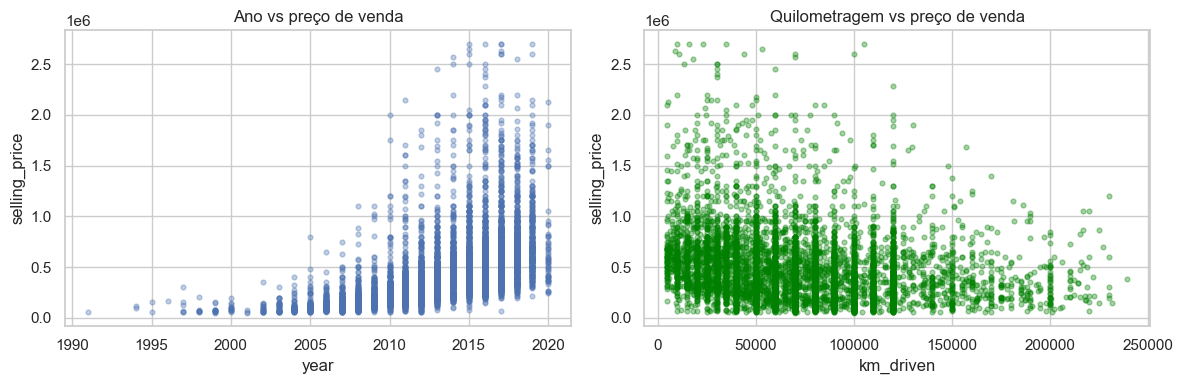

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["year"], df["selling_price"], alpha=0.35, s=12)
axes[0].set_title("Ano vs preço de venda")
axes[0].set_xlabel("year")
axes[0].set_ylabel("selling_price")

axes[1].scatter(df["km_driven"], df["selling_price"], alpha=0.35, s=12, color="green")
axes[1].set_title("Quilometragem vs preço de venda")
axes[1].set_xlabel("km_driven")
axes[1].set_ylabel("selling_price")

plt.tight_layout()
plt.show()


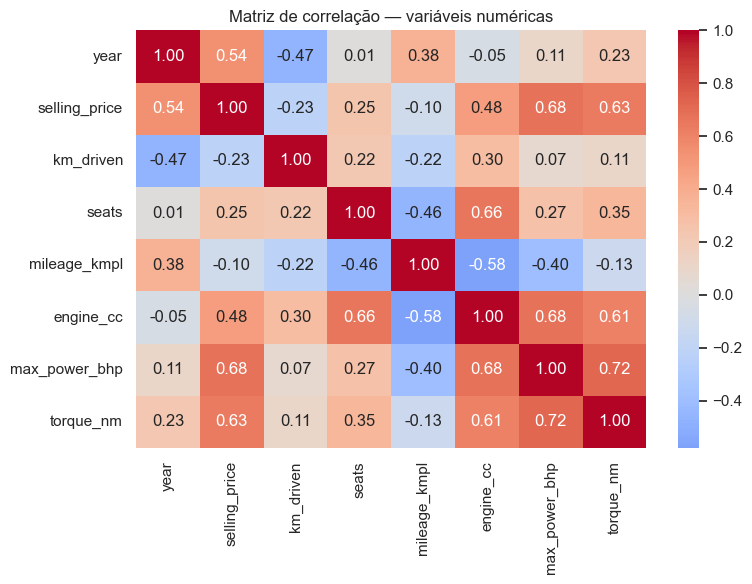

In [6]:
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação — variáveis numéricas")
plt.tight_layout()
plt.show()


## 3. Preparação para modelagem


In [7]:
TARGET = "selling_price"

numeric_features = [
    "year", "km_driven", "seats",
    "mileage_kmpl", "engine_cc", "max_power_bhp", "torque_nm",
]
categorical_features = ["fuel", "seller_type", "transmission", "owner", "brand"]

feature_cols = numeric_features + categorical_features
model_df = df[feature_cols + [TARGET]].copy()

X = model_df[feature_cols]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Amostras de treino: {len(X_train):,}")
print(f"Amostras de teste: {len(X_test):,}")


Amostras de treino: 5,330
Amostras de teste: 1,333


In [8]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


def build_pipeline(model):
    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test):
    cv = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"],
        return_train_score=False,
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results = {
        "modelo": name,
        "cv_mae": -cv["test_neg_mean_absolute_error"].mean(),
        "cv_mae_std": cv["test_neg_mean_absolute_error"].std(),
        "cv_rmse": -cv["test_neg_root_mean_squared_error"].mean(),
        "cv_rmse_std": cv["test_neg_root_mean_squared_error"].std(),
        "cv_r2": cv["test_r2"].mean(),
        "cv_r2_std": cv["test_r2"].std(),
        "test_mae": mean_absolute_error(y_test, y_pred),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "test_r2": r2_score(y_test, y_pred),
    }
    return results, pipeline


## 4. Modelagem com cross-validation


In [9]:
models = {
    "Regressão Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "KNN": KNeighborsRegressor(n_neighbors=7, weights="distance"),
}

all_results = []
fitted = {}

for name, estimator in models.items():
    pipe = build_pipeline(estimator)
    res, fitted_pipe = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
    all_results.append(res)
    fitted[name] = fitted_pipe
    print(
        f"{name}: CV MAE={res['cv_mae']:,.0f} | CV RMSE={res['cv_rmse']:,.0f} | CV R²={res['cv_r2']:.3f}"
    )

results_df = pd.DataFrame(all_results).set_index("modelo")
results_df.round(3)


Regressão Linear: CV MAE=109,243 | CV RMSE=158,454 | CV R²=0.790
Random Forest: CV MAE=71,304 | CV RMSE=116,317 | CV R²=0.887
KNN: CV MAE=81,261 | CV RMSE=131,306 | CV R²=0.856


,cv_mae,cv_mae_std,cv_rmse,cv_rmse_std,cv_r2,cv_r2_std,test_mae,test_rmse,test_r2
modelo,,,,,,,,,
Regressão Linear,109242.529,4154.214,158453.725,7700.842,0.790,0.016,110375.996,164388.092,0.784
Random Forest,71304.293,2127.757,116317.323,3193.230,0.887,0.004,68755.880,117420.362,0.890
KNN,81260.924,1142.204,131306.230,4227.726,0.856,0.011,81103.792,132221.694,0.860


## 5. Comparação de desempenho


,cv_mae,cv_rmse,cv_r2
modelo,,,
Regressão Linear,109242.529,158453.725,0.790
Random Forest,71304.293,116317.323,0.887
KNN,81260.924,131306.230,0.856


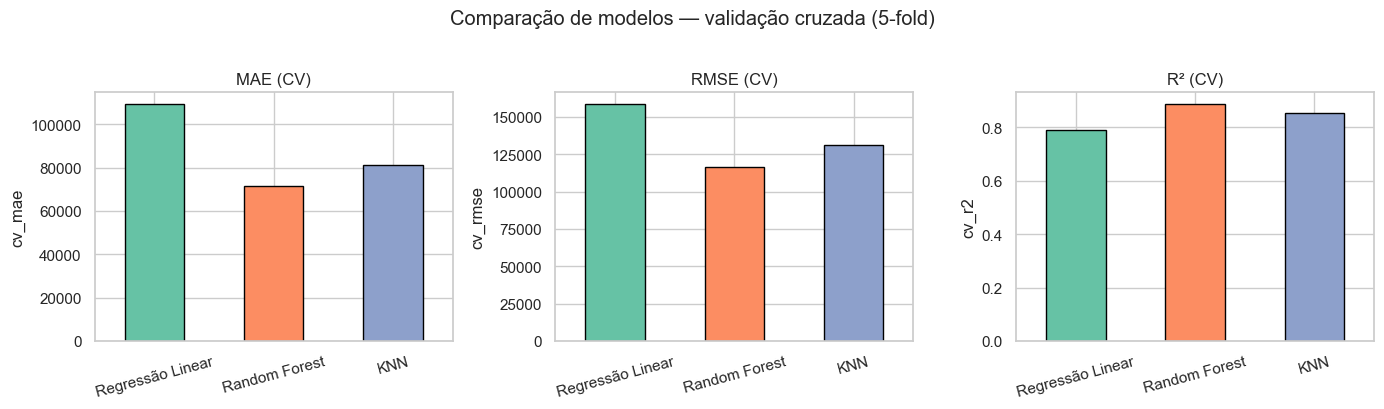

Melhor modelo (menor RMSE na CV): Random Forest


In [10]:
metrics = ["cv_mae", "cv_rmse", "cv_r2"]
display(results_df[metrics].round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = sns.color_palette("Set2", n_colors=len(results_df))

for ax, metric, title in zip(
    axes,
    ["cv_mae", "cv_rmse", "cv_r2"],
    ["MAE (CV)", "RMSE (CV)", "R² (CV)"],
):
    results_df[metric].plot(kind="bar", ax=ax, color=colors, edgecolor="black")
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Comparação de modelos — validação cruzada (5-fold)", y=1.02)
plt.tight_layout()
plt.show()

best_model_name = results_df["cv_rmse"].idxmin()
print(f"Melhor modelo (menor RMSE na CV): {best_model_name}")


## 6. Interpretação — importância das variáveis


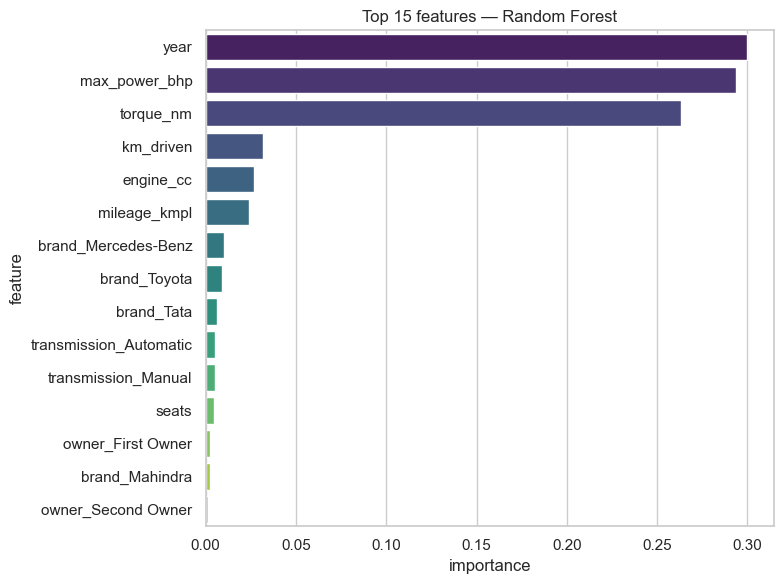

,feature,importance
0,year,0.299688
5,max_power_bhp,0.293601
6,torque_nm,0.263433
1,km_driven,0.031695
4,engine_cc,0.027010
3,mileage_kmpl,0.024212
40,brand_Mercedes-Benz,0.010121
48,brand_Toyota,0.008991
47,brand_Tata,0.006053
14,transmission_Automatic,0.004986


In [11]:
def get_feature_names(preprocessor):
    num_names = numeric_features
    cat_names = list(
        preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(
            categorical_features
        )
    )
    return num_names + cat_names


best_pipe = fitted[best_model_name]
feature_names = get_feature_names(best_pipe.named_steps["preprocessor"])

if hasattr(best_pipe.named_steps["model"], "feature_importances_"):
    importances = best_pipe.named_steps["model"].feature_importances_
    imp_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, y="feature", x="importance", palette="viridis")
    plt.title(f"Top 15 features — {best_model_name}")
    plt.tight_layout()
    plt.show()
    display(imp_df)
else:
    coefs = best_pipe.named_steps["model"].coef_
    coef_df = (
        pd.DataFrame({"feature": feature_names, "coeficiente": coefs})
        .assign(abs_coef=lambda d: d["coeficiente"].abs())
        .sort_values("abs_coef", ascending=False)
        .head(15)
    )
    display(coef_df[["feature", "coeficiente"]])


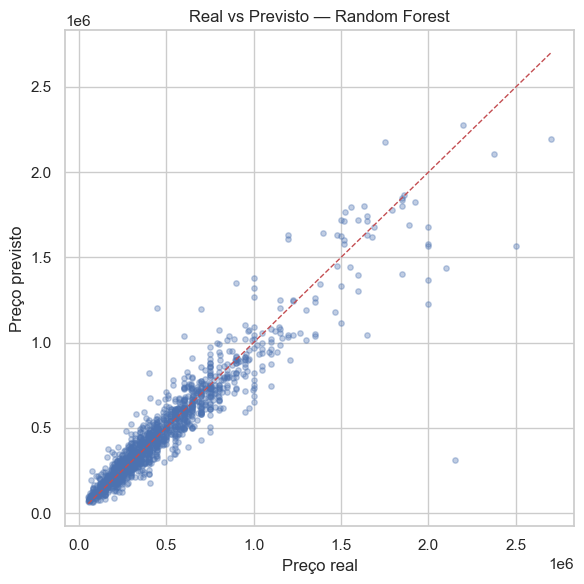

Resumo final no conjunto de teste:


,test_mae,test_rmse,test_r2
modelo,,,
Regressão Linear,110375.996,164388.092,0.784
Random Forest,68755.880,117420.362,0.890
KNN,81103.792,132221.694,0.860


In [12]:
y_pred_best = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_best, alpha=0.35, s=15)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Preço real")
ax.set_ylabel("Preço previsto")
ax.set_title(f"Real vs Previsto — {best_model_name}")
plt.tight_layout()
plt.show()

print("Resumo final no conjunto de teste:")
display(results_df[["test_mae", "test_rmse", "test_r2"]].round(3))


## 7. Conclusões

- O dataset **Car details v3.csv** é adequado ao projeto após deduplicação, parsing de campos textuais e remoção de outliers extremos.
- Foram comparados três algoritmos com **validação cruzada 5-fold**: Regressão Linear, Random Forest e KNN.
- Modelos baseados em árvores tendem a capturar melhor relações não lineares entre marca, ano, potência e preço.
- As variáveis mais relevantes incluem **ano**, **quilometragem** e atributos técnicos do motor, além de categorias como **marca** e **combustível**.
- Os resultados deste notebook alimentam o relatório e a apresentação do seminário.
